Saved: transform_given_breakpoints.png
Saved: transform_smooth_breakpoints.png


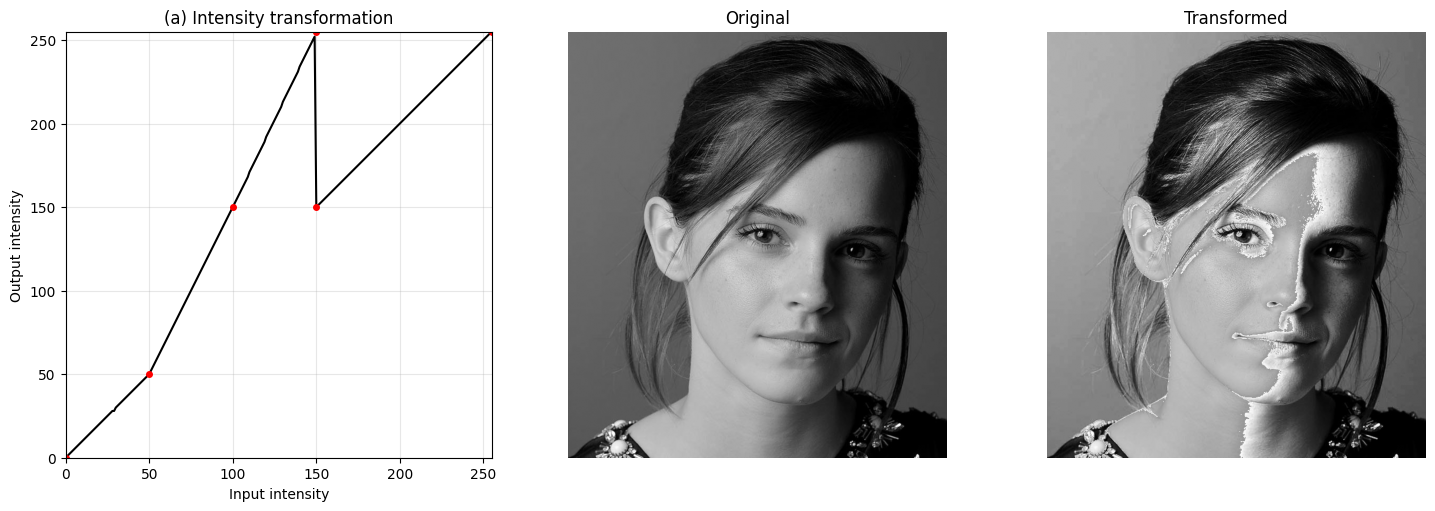

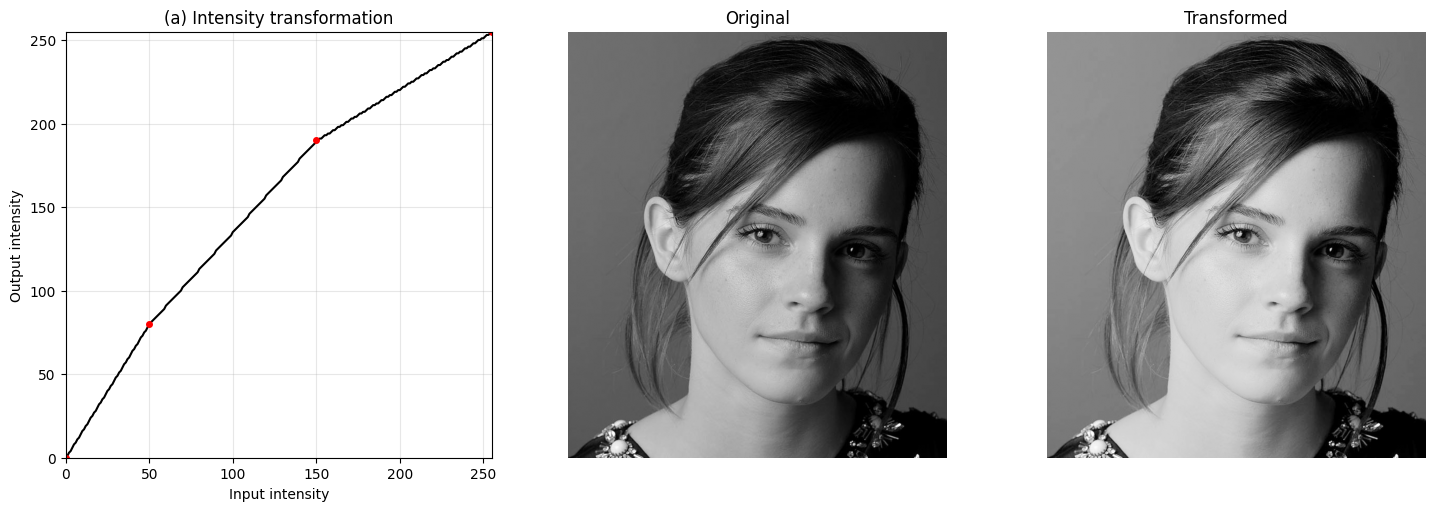

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def intensity_transform(im, breakpoints):

    bp = np.asarray(breakpoints, dtype=np.float64)
    xs, ys = bp[:, 0], bp[:, 1]

    if np.any(np.diff(xs) < 0):
        raise ValueError("breakpoint x-values must be non-decreasing")

    lut = np.zeros(256, dtype=np.float64)

    
    for v in range(256):
       
        idx = np.searchsorted(xs, v, side="right") - 1
        idx = np.clip(idx, 0, len(xs) - 2)

        x0, x1 = xs[idx], xs[idx + 1]
        y0, y1 = ys[idx], ys[idx + 1]

        if x1 == x0:
            lut[v] = y1  
        else:
            t = (v - x0) / (x1 - x0)
            lut[v] = y0 + t * (y1 - y0)

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    im_uint8 = np.clip(im, 0, 255).astype(np.uint8)
    out = lut[im_uint8]
    return out, lut


def plot_results(im, out, lut, breakpoints, save_path):
    bp = np.asarray(breakpoints)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].plot(np.arange(256), lut, color="black", linewidth=1.5)
    axes[0].plot(bp[:, 0], bp[:, 1], "o", color="red", markersize=4)
    axes[0].set_xlim(0, 255)
    axes[0].set_ylim(0, 255)
    axes[0].set_xlabel("Input intensity")
    axes[0].set_ylabel("Output intensity")
    axes[0].set_title("(a) Intensity transformation")
    axes[0].set_aspect("equal")
    axes[0].grid(alpha=0.3)

    axes[1].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Original")
    axes[1].axis("off")

    axes[2].imshow(out, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Transformed")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Saved: {save_path}")


if __name__ == "__main__":
    path = "images/emma_gray.jpg"
    im = np.array(Image.open(path).convert("L"))

breakpoints_given = [
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [150, 150],
    [255, 255],
]
out1, lut1 = intensity_transform(im, breakpoints_given)
plot_results(im, out1, lut1, breakpoints_given, "transform_given_breakpoints.png")

breakpoints_smooth = [
    [0,   0],
    [50,  80],
    [150, 190],
    [255, 255],
]
out2, lut2 = intensity_transform(im, breakpoints_smooth)
plot_results(im, out2, lut2, breakpoints_smooth, "transform_smooth_breakpoints.png")
